In [ ]:


from matplotlib import pyplot as plt
"""
This notebook generates the figures presented in the paper. If other data should be used the paths in the cells need to be adapted
"""
import os

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "axes.grid" : True,
    "axes.linewidth": 0.75,
    "pgf.preamble": "\n".join([r'\usepackage{amsmath}', r'\usepackage{bm}', r'\usepackage{amsfonts}', r'\usepackage{amssymb}'])
})
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{bm} \usepackage{amsfonts} \usepackage{amssymb}')

parent_dir =  os.path.dirname(os.getcwd())

pts2inch = 1/72.27
ratio = 1.618
max_pts = 433
frac = 0.6

violations: 2
violations: 0
violations: 0
violations: 1


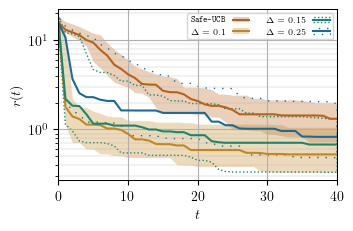

In [ ]:
import pickle
import torch
from scipy import stats


fig,ax = plt.subplots(1,figsize=(max_pts*frac*pts2inch,max_pts*frac/ratio*pts2inch))
files = [
    parent_dir+"/data/Bayes_ST/LbSync_13.obj",
    parent_dir+"/data/Bayes_MT/LbSync_dist_10.obj",
    parent_dir+"/data/Bayes_MT/LbSync_dist_15.obj",
    parent_dir+"/data/Bayes_MT/LbSync_dist_25.obj"
        ]
color = [[186,97,26],
        [194,135,32],
        [21,138,106],
        [23,108,155]]
def _load_final_regrets(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    vals = -torch.tensor([y[-1] for y in data['bests']])
    return vals.float()

def plot2(ax,str,i,best):
    if str.find('.obj') != -1:
        with open(str,'rb') as file:
            data = pickle.load(file)
            best_values = -torch.tensor([y[-1] for y in data['bests']])-best
            #best_values = best_values - torch.min(best_values)
            q25, q75 = torch.quantile(best_values, 0.25, dim=0), torch.quantile(best_values, 0.75, dim=0)
            muy = torch.median(best_values,dim=0).values
            vios = 0
            for set in data['data_sets']:
                xt,tt,yt = tuple(set)
                yt0 = yt[tt.squeeze() == 0].squeeze()
                vios += torch.sum(-yt0[:40]>40)
            print(f"violations: {vios}")
    x = torch.arange(len(muy))
    if i >1:
        fill = ax.fill_between(x,q25,q75, edgecolor=[color[i][j]/255 for j in range(3)],alpha=1, facecolor = 'none', linewidth=1, linestyle = ':' if i==2 else (0,(1,5)))
    else:
        fill = ax.fill_between(x,q25,q75,color=[color[i][j]/255 for j in range(3)],alpha=.3, linewidth=0)
    line,= ax.plot(x,muy, color=[color[i][j]/255 for j in range(3)],linestyle = '-' if i==3 else '-')
    return (line,fill)

def get_best(files):
    best = torch.zeros(len(files))
    for i in range(len(files)):
        with open(files[i],'rb') as file:
                data = pickle.load(file)
                best_values = -torch.tensor([y[-1] for y in data['bests']])
                best[i] = torch.min(best_values)
    return torch.min(best)

h = []
for i in range(len(files)):
    h.append(plot2(ax,files[i],i,get_best(files)))


leg = ax.legend(h,[r"\texttt{Safe-UCB}",r"$\Delta = 0.1$",r"$\Delta = 0.15$",r"$\Delta = 0.25$"], markerfirst=False, title_fontsize=7, loc='upper right', ncol=2)
ax.set_xlim(0,40)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r" $r(t)$")
ax.set_yscale('log',base=10)
ax.grid(which='minor', axis='y', linestyle='-',linewidth=0.25 )
fig.savefig(parent_dir+"/plots/laser_chain_comp_1.pdf", bbox_inches='tight')